# Multidimensional-state Stochastic Optimal Growth Model with Leisure

This notebook replicates and solves a multidimensional-state dynamic programming problem given in Santos (1999).

We consider the stochastic optimal growth model with leisure from Santos (1999) Section 7.3:

\begin{align*}
    \max_{\{c_t, l_t\}} \mathbb{E}_0 \sum_{t=0}^{\infty} \beta^t
    \left[ \lambda \log c_t + (1 - \lambda) \log l_t \right]
\end{align*}

subject to

\begin{align*}
c_t + k_{t+1} &= z_t A k_t^\alpha (1 - l_t)^{1-\alpha} + (1 - \delta) k_t,\\
\log z_{t+1} &= \rho \log z_t + \varepsilon_{t+1}.
\end{align*}

Here, we let $s = (k, \log{z})$ represent the two-dimensional state of capital $k$ and log productivity $\log{z}$, $x$ the leisure ($l$), and $\varepsilon$ denote the random productivity shock.

Following Santos (1999), we reduce the problem to a unidimensional maximization over leisure $x$.

In [1]:
# Import libraries
using BasisMatrices
using ContinuousDPs
using DataFrames
using PythonPlot
using QuantEcon
using Random

const plt = PythonPlot.pyplot;

In [2]:
# For reproducible results
seed = 42
rng = MersenneTwister(seed);

## Model setup

As in Santos (1999) Sec. 7.3 Table 16, we specify the structural parameters as follows.

In [3]:
function MultidimOptimalGrowthModel(;
        # Model parameters
        beta = 0.95, lambda = 1 / 3, A = 10.0, alpha = 0.34, delta = 1.0, rho = 0.90, 
        sigma_epsilon = 0.008, 
        # State domains
        logz_min = -0.32, logz_max = 0.32, 
        k_min = 0.10, k_max = 10.0,
        # Action bounds for numerical stability (leisure x in (0, 1))
        x_min = 1e-10, x_max = 1 - 1e-10
    )
    # Production function
    y(k, z, x) = z * A * k^alpha * (1 - x)^(1 - alpha)
    
    # Consumption and k prime based on Santos equation (7.4)
    function c_from_x(k, z, x) 
        term1 = z * A * k^alpha * (1 - x)^(-alpha)
        term2 = (lambda / (1 - lambda)) * (1 - alpha) * x
        return term1 * term2
    end

    # Next period capital 
    kprime_from_x(k, z, x) = y(k, z, x) + (1 - delta) * k - c_from_x(k, z, x)

    # Reward function
    function f(s, x)
        k, logz = s
        z = exp(logz)
        if !(0 < x < 1)
            return -Inf
        end
        c = c_from_x(k, z, x)
        kp = kprime_from_x(k, z, x)
        if c <= 0 || kp < 0
            return -Inf
        end
        return lambda * log(c) + (1 - lambda) * log(x)
    end

    # Transition function
    function g(s, x, e)
        k, logz = s
        z = exp(logz)
        kp = kprime_from_x(k, z, x)
        logzp = rho * logz + e
        return (kp, logzp)
    end

    x_lb(_) = x_min
    x_ub(_) = x_max
    
    # NamedTuple of model components
    return (; beta, lambda, A, alpha, delta, rho, sigma_epsilon, 
            logz_min, logz_max, k_min, k_max, x_lb, x_ub, f, g, kprime_from_x)
end

p = MultidimOptimalGrowthModel();

For $\delta = 1$ (full depreciation), the optimal leisure is constant, and we have analytical benchmark solutions for the value and policy functions:

In [4]:
ab = p.alpha * p.beta

# Optimal leisure (constant)
x_star_numerator = (1 - p.lambda) * (1 - ab)
x_star_denominator = p.lambda * (1 - p.alpha) + ((1 - p.lambda) * (1 - ab))
x_star = x_star_numerator / x_star_denominator

# Policy function (constant fraction of production)
policy(k, logz) = ab * exp(logz) * p.A * k^p.alpha * (1 - x_star)^(1 - p.alpha)

# Value function: V(k, z) = B + C*log(k) + D*log(z)
C = p.lambda * p.alpha / (1 - ab)
D = p.lambda / ((1 - ab) * (1 - p.rho * p.beta))
const_term1 = p.lambda * (log(1 - ab) + log(p.A) + (1 - p.alpha) * log(1 - x_star))
const_term2 = (1 - p.lambda) * log(x_star) 
const_term3 = p.beta * C * (log(ab) + log(p.A) + (1 - p.alpha) * log(1 - x_star))
B = (const_term1 + const_term2 + const_term3) / (1 - p.beta)
v_star(k, logz) = B + C * log(k) + D * logz;

We discretize the shock distribution by the Gauss-Hermite quadrature:

In [5]:
n_shocks = 7
shocks, weights = qnwnorm(n_shocks, 0.0, p.sigma_epsilon^2);

Set up grid size settings for $k$ and $\log(z)$, with mesh size $h$.

In [6]:
function GridToleranceSettings(p)
    function mesh_info(p, nk, nlogz)
        grid_size_k = (p.k_max - p.k_min) / (nk - 1)
        grid_size_logz = (p.logz_max - p.logz_min) / (nlogz - 1)
        mesh_size_h = sqrt(grid_size_k^2 + grid_size_logz^2)
        return (; nk, nlogz, grid_size_k, grid_size_logz, mesh_size_h)
    end

    linear_tolerances(h) = (;
        linear_policy_tol = 0.4 * h,
        linear_value_tol = 24 * h^2
    )

    base_settings = [
        (nk = 43, nlogz = 3, spline_policy_tol = 1.92e-2, spline_value_tol = 9.58e-1),
        (nk = 143, nlogz = 9, spline_policy_tol = 3.11e-3, spline_value_tol = 4.99e-3),
        (nk = 500, nlogz = 33, spline_policy_tol = 3.82e-4, spline_value_tol = 2.42e-5)
    ]

    return [
        begin
            info = mesh_info(p, setting.nk, setting.nlogz)
            
            linear_tols= linear_tolerances(info.mesh_size_h)

            merge(setting, linear_tols, info)
        end    
        for setting in base_settings
    ]
end

grid_tol_settings = GridToleranceSettings(p);

Set up a helper function to calculate errors relative to benchmark solutions:

In [7]:
function calculate_errors(p, cdp, res, v_star, policy)
    # Analytical targets on interpolation nodes
    S = cdp.interp.S
    k_nodes = @view S[:, 1]
    logz_nodes = @view S[:, 2]

    v_star_on_S = v_star.(k_nodes, logz_nodes)
    k_prime_star_on_S = policy.(k_nodes, logz_nodes)

    x_hat = vec(res.X)
    k_hat = first.(p.g.(eachrow(S), x_hat, 0.0))

    policy_error = maximum(abs, k_hat .- k_prime_star_on_S)
    value_error = maximum(abs, res.V .- v_star_on_S)

    return (; policy_error, value_error)
end;

## Baseline

Set up the baseline smallest grid below, and let us construct a `Basis` object from `BasisMatrices.jl` using a Linear basis:

In [8]:
# The smallest grid in Santos, 1999, Table 16
baseline_case = grid_tol_settings[1]
nk, nlogz = baseline_case.nk, baseline_case.nlogz

# Construct basis
basis = Basis(
    LinParams(nk, p.k_min, p.k_max),
    LinParams(nlogz, p.logz_min, p.logz_max)
);

Construct a `ContinuousDP` instance:

In [9]:
cdp = ContinuousDP(p.f, p.g, p.beta, shocks, weights, p.x_lb, p.x_ub, basis);

### Solving the model

Let us now solve the model with the policy function iteration (PFI):

In [10]:
res = solve(cdp);

Compute iterate 8 with error 7.740026397584643e-10
Converged in 8 steps


Let us compare the results with benchmark analytical solutions. We look at the policy function and value function at the interpolation nodes:

In [11]:
baseline_errors = calculate_errors(p, cdp, res, v_star, policy)

# Value and policy functions benchmark check
println("converged = ", res.converged)
println("max |k'_hat - k'_star| = ", baseline_errors.policy_error)
println(
    "max |k'_hat - k'_star| <= policy_tol: ", 
    baseline_errors.policy_error <= baseline_case.linear_policy_tol
)
println("max |V_hat - V_star|  = ", baseline_errors.value_error)
println(
    "max |V_hat - V_star| <= value_tol: ", 
    baseline_errors.value_error <= baseline_case.linear_value_tol
)

converged = true
max |k'_hat - k'_star| = 0.13631492104008025
max |k'_hat - k'_star| <= policy_tol: true
max |V_hat - V_star|  = 0.004781312201232346
max |V_hat - V_star| <= value_tol: true


### Figures

In [12]:
# Evaluate the solution on a user-specified grid
k_eval_grid = collect(range(p.k_min, p.k_max, length=15))
logz_eval_grid = collect(range(p.logz_min, p.logz_max, length=7))
set_eval_nodes!(res, k_eval_grid, logz_eval_grid)
V_eval, X_eval, resid_eval = res(res.eval_nodes)

# Helper for one-dimensional slices used below
function evaluate_slice!(res, k_grid, logz0)
    set_eval_nodes!(res, k_grid, [logz0])
    V_slice, X_slice, resid_slice = res(res.eval_nodes)
    return vec(V_slice), vec(X_slice), vec(resid_slice)
end;

Now let us simulate the solved model, starting from $ s_{0} = (0.1, 0.0)$ for $50$ periods:

all(k_path .>= k_min) && all(k_path .<= k_max): true
all(logz_path .>= logz_min) && all(logz_path .<= logz_max): true


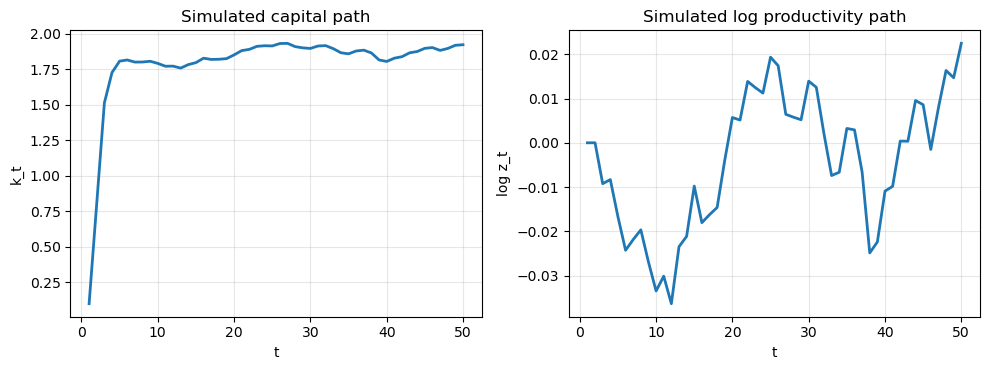

In [13]:
s_init = [0.1, 0.0]
ts_length = 50
sim_rng = MersenneTwister(seed)

s_path = simulate(sim_rng, res, s_init, ts_length)
k_path = @view s_path[1, :]
logz_path = @view s_path[2, :]

println("all(k_path .>= k_min) && all(k_path .<= k_max): ",
        all(k_path .>= p.k_min) && all(k_path .<= p.k_max))
println("all(logz_path .>= logz_min) && all(logz_path .<= logz_max): ",
        all(logz_path .>= p.logz_min) && all(logz_path .<= p.logz_max))

fig = plt.figure(figsize=(10, 3.8))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(1:ts_length, k_path, lw=2)
ax1.set_title("Simulated capital path")
ax1.set_xlabel("t")
ax1.set_ylabel("k_t")
ax1.grid(true, alpha=0.3)

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(1:ts_length, logz_path, lw=2)
ax2.set_title("Simulated log productivity path")
ax2.set_xlabel("t")
ax2.set_ylabel("log z_t")
ax2.grid(true, alpha=0.3)

fig.tight_layout()
display(fig)


Plot the policy functions against analytical benchmark solutions:

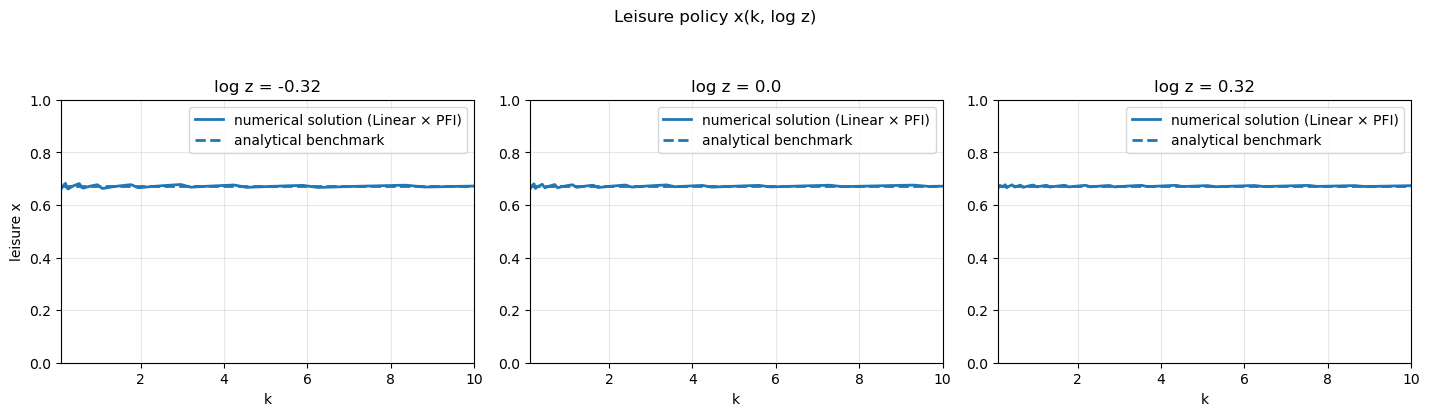

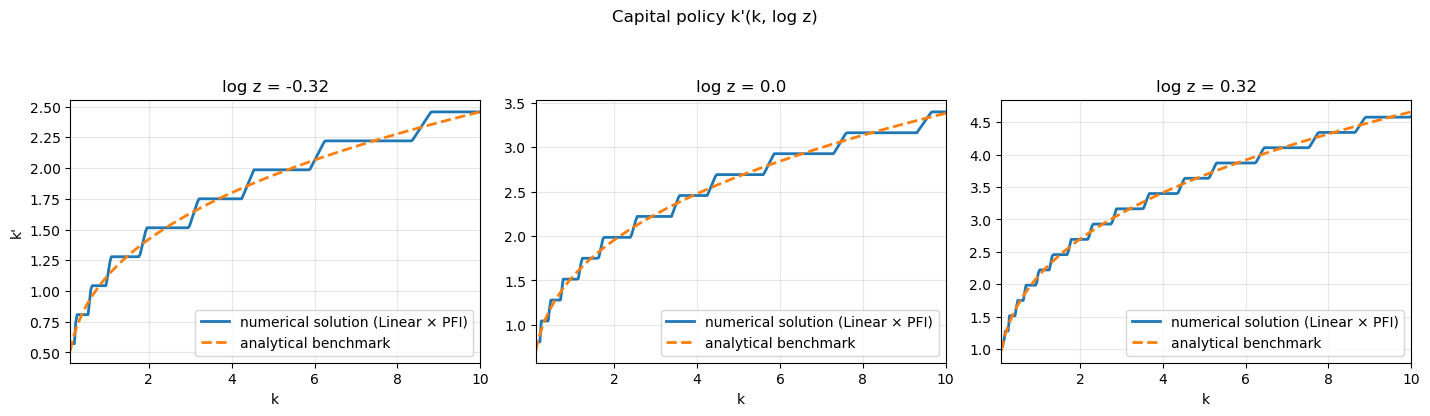

In [14]:
basis_name = "Linear"
method_name = "PFI"
tag = "$(basis_name) × $(method_name)"
lbl_approx = "numerical solution ($tag)"
lbl_bench  = "analytical benchmark"

k_plot_grid = collect(range(p.k_min, p.k_max, length=300))
logz_slices = [p.logz_min, 0.0, p.logz_max]
ncols = length(logz_slices)

# Leisure policy x(k, log z)
fig = plt.figure(figsize=(4.8 * ncols, 4.2))

for (j, logz0) in enumerate(logz_slices)
    ax = fig.add_subplot(1, ncols, j)

    _, x_hat_slice, _ = evaluate_slice!(res, k_plot_grid, logz0)

    ax.plot(k_plot_grid, x_hat_slice, lw=2, label=lbl_approx)
    ax.axhline(x_star, lw=2, linestyle="--", label=lbl_bench)

    ax.set_title("log z = $(round(logz0, digits=2))")
    ax.set_xlabel("k")
    if j == 1
        ax.set_ylabel("leisure x")
    end
    ax.set_xlim(p.k_min, p.k_max)
    ax.set_ylim(0.0, 1.0)
    ax.grid(true, alpha=0.3)
    ax.legend()
end

fig.suptitle("Leisure policy x(k, log z)")
fig.tight_layout(rect=[0, 0, 1, 0.92])
display(fig)

# Implied k'(k, log z) policy
fig = plt.figure(figsize=(4.8 * ncols, 4.2))

for (j, logz0) in enumerate(logz_slices)
    ax = fig.add_subplot(1, ncols, j)

    _, x_hat_slice, _ = evaluate_slice!(res, k_plot_grid, logz0)
    kp_hat = [p.kprime_from_x(k_plot_grid[i], exp(logz0), x_hat_slice[i]) for i in eachindex(k_plot_grid)]
    kp_bench = policy.(k_plot_grid, logz0)

    ax.plot(k_plot_grid, kp_hat, lw=2, label=lbl_approx)
    ax.plot(k_plot_grid, kp_bench, lw=2, linestyle="--", label=lbl_bench)

    ax.set_title("log z = $(round(logz0, digits=2))")
    ax.set_xlabel("k")
    if j == 1
        ax.set_ylabel("k'")
    end
    ax.set_xlim(p.k_min, p.k_max)
    ax.grid(true, alpha=0.3)
    ax.legend()
end

fig.suptitle("Capital policy k'(k, log z)")
fig.tight_layout(rect=[0, 0, 1, 0.92])
display(fig)


Next, plot the value function against benchmark solutions:

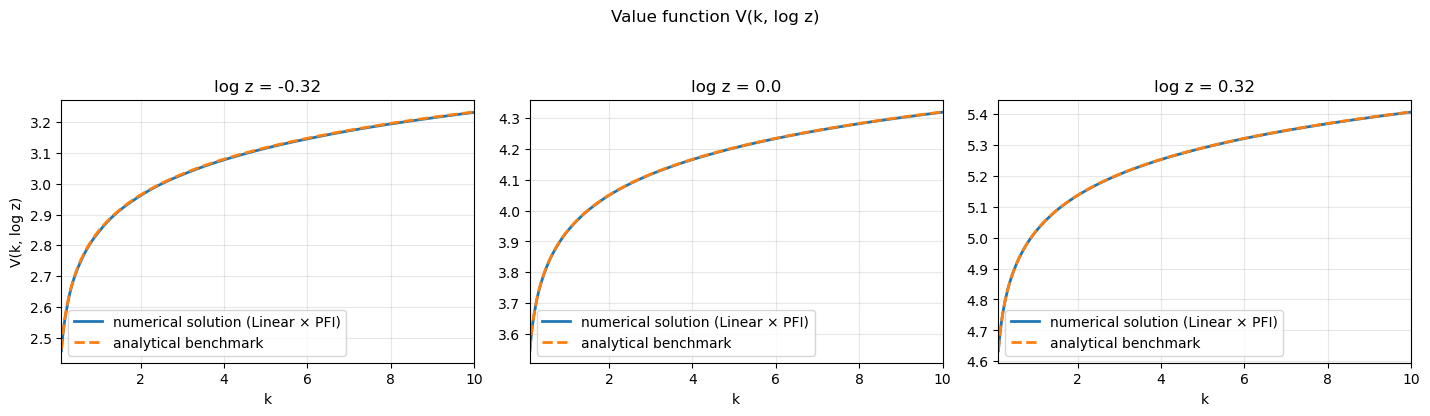

In [15]:
fig = plt.figure(figsize=(4.8 * ncols, 4.2))

for (j, logz0) in enumerate(logz_slices)
    ax = fig.add_subplot(1, ncols, j)

    V_hat_slice, _, _ = evaluate_slice!(res, k_plot_grid, logz0)
    V_bench = v_star.(k_plot_grid, logz0)

    ax.plot(k_plot_grid, V_hat_slice, lw=2, label=lbl_approx)
    ax.plot(k_plot_grid, V_bench, lw=2, linestyle="--", label=lbl_bench)

    ax.set_title("log z = $(round(logz0, digits=2))")
    ax.set_xlabel("k")
    if j == 1
        ax.set_ylabel("V(k, log z)")
    end
    ax.set_xlim(p.k_min, p.k_max)
    ax.grid(true, alpha=0.3)
    ax.legend()
end

fig.suptitle("Value function V(k, log z)")
fig.tight_layout(rect=[0, 0, 1, 0.92])
display(fig)


## Santos (1999) Replication

We now replicate the results from Santos (1999). Specifically, Table 16 in the paper reports the accuracy of VFI using linear interpolation, while Table 20 uses spline interpolation, both evaluated across three different grid sizes.

Set up a helper function to show a clear table:

In [17]:
function print_table(df)
    html = sprint(io -> show(io, MIME("text/html"), df;
        summary=false,
        eltypes=false,
    ))
    display("text/html", html)
    return nothing
end;

### Table 16: VFI with Linear Interpolation

In [ ]:
table16_rows = NamedTuple[]
println(
    "Policy and value functions meet the tolerance specified in Table 16: "
)
for (; nk, nlogz, linear_policy_tol, linear_value_tol, mesh_size_h) in grid_tol_settings
    basis = Basis(
        LinParams(nk, p.k_min, p.k_max),
        LinParams(nlogz, p.logz_min, p.logz_max)
    )

    cdp = ContinuousDP(p.f, p.g, p.beta, shocks, weights, p.x_lb, p.x_ub, basis)
    (; value, time) = @timed solve(cdp, VFI, verbose=1); # verbose=1: warnings only
    res = value

    baseline_errors = calculate_errors(p, cdp, res, v_star, policy)

    is_passed_policy = baseline_errors.policy_error <= linear_policy_tol
    is_passed_value = baseline_errors.value_error <= linear_value_tol
    
    println(
        " - (nk x nlogz) = ($nk x $nlogz) -> \
        Policy: $is_passed_policy, Value: $is_passed_value"
    )
    
    # create dataframe replicating Table 16 in Santos (1999)
    push!(table16_rows, (
        vertex_points = "$nk x $nlogz", 
        mesh_size = mesh_size_h,
        iterations = res.num_iter,
        cpu_time = time,
        policy_error = baseline_errors.policy_error, 
        value_error = baseline_errors.value_error, 
    ))
end

Policy and value functions meet the tolerance specified in Table 16: 
 - (nk x nlogz) = (43 x 3) -> Policy: true, Value: true


As we can see, the iteration converges much faster than in Santos (1999) on finer grids. Value functions achieve greater accuracy as well.

In [19]:
table16_df = DataFrame(table16_rows)
print_table(table16_df)

Row,vertex_points,mesh_size,iterations,cpu_time,policy_error,value_error
1,43 x 3,0.397443,321,2.03676,0.136315,0.00478157
2,143 x 9,0.106116,321,21.6,0.0381337,0.000472691
3,500 x 33,0.0281711,321,259.987,0.0105872,5.1058e-5


### Table 20: VFI with Spline Interpolation

In [ ]:
table20_rows = NamedTuple[]
deg_k, deg_z = 2, 3
println(
    "Policy and value functions meet the tolerance specified in Table 20: "
)
for (; nk, nlogz, spline_policy_tol, spline_value_tol, mesh_size_h) in grid_tol_settings
    dk = min(deg_k, nk - 1)
    dz = min(deg_z, nlogz - 1)
    breaks_k = nk - (dk - 1)
    breaks_z = nlogz - (dz - 1)

    basis = Basis(
        SplineParams(breaks_k, p.k_min, p.k_max, dk),
        SplineParams(breaks_z, p.logz_min, p.logz_max, dz)
    )

    cdp = ContinuousDP(p.f, p.g, p.beta, shocks, weights, p.x_lb, p.x_ub, basis)
    (; value, time) = @timed solve(cdp, VFI, verbose=1); # verbose=1: warnings only
    res = value

    baseline_errors = calculate_errors(p, cdp, res, v_star, policy)
    
    is_passed_policy = baseline_errors.policy_error <= spline_policy_tol
    is_passed_value = baseline_errors.value_error <= spline_value_tol
    
    println(
        " - (nk x nlogz) = ($nk x $nlogz) -> \
        Policy: $is_passed_policy, Value: $is_passed_value"
    )

    # create dataframe replicating Table 20 in Santos (1999) (excluding CPU time)
    push!(table20_rows, (
        vertex_points = "$(nk) x $(nlogz)", 
        mesh_size = mesh_size_h,
        iterations = res.num_iter,
        cpu_time = time,
        policy_error = baseline_errors.policy_error, 
        value_error = baseline_errors.value_error, 
    ))
end

Policy and value functions meet the tolerance specified in Table 20: 
 - (nk x nlogz) = (43 x 3) -> Policy: true, Value: true
 - (nk x nlogz) = (143 x 9) -> Policy: true, Value: true
 - (nk x nlogz) = (500 x 33) -> Policy: true, Value: true


As we can see, the iteration converges much faster than in Santos (1999) on finer grids. Policy and value functions achieve greater accuracy as well.

In [21]:
table20_df = DataFrame(table20_rows)
print_table(table20_df)

Row,vertex_points,mesh_size,iterations,cpu_time,policy_error,value_error
1,43 x 3,0.397443,321,1.41137,0.0108865,0.00025977
2,143 x 9,0.106116,321,17.1634,0.000752714,6.57455e-6
3,500 x 33,0.0281711,321,291.091,9.4397e-5,4.00999e-7
